**Assignment 1:  Portfolio Optimisation with Linear Regression and CAMP**


In [29]:
!pip install yfinance
import pandas as pd
import datetime as dt
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import linregress
!pip install gurobipy
import gurobipy as gp
from gurobipy import GRB


In [ ]:
assets= ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NFLX', 'NVDA', 'JPM', 'V']
market_index = '^GSPC' # S&P 500


In [ ]:
start = dt.datetime(2019,1,1) # the 5 year period
end =  dt.datetime(2023,12,31)

In [ ]:
market_data = yf.download(market_index, start,end)["Close"] # downloads closing prices of the stock prices of all 500 companies


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [ ]:
market_daily_returns = market_data.copy().pct_change().dropna() # calculate daily returns of the S&P 500
market_daily_returns

Ticker,^GSPC
Date,
2019-01-03,-0.024757
2019-01-04,0.034336
2019-01-07,0.007010
2019-01-08,0.009695
2019-01-09,0.004098
...,...
2023-12-22,0.001660
2023-12-26,0.004232
2023-12-27,0.001430


In [ ]:
data = yf.download(assets, start,end)["Close"] # downloads the asset closing prices


[*********************100%***********************]  10 of 10 completed


In [ ]:

assets_daily_returns = data.copy().pct_change().dropna() # calculate daily returns of the the 10 assets
assets_daily_returns


Ticker,AAPL,AMZN,GOOGL,JPM,META,MSFT,NFLX,NVDA,TSLA,V
Date,,,,,,,,,,
2019-01-03,-0.099607,-0.025241,-0.027696,-0.014212,-0.029039,-0.036788,0.013226,-0.060417,-0.031472,-0.036037
2019-01-04,0.042689,0.050064,0.051294,0.036865,0.047138,0.046509,0.097234,0.064068,0.057697,0.043081
2019-01-07,-0.002226,0.034353,-0.001994,0.000695,0.000725,0.001276,0.059717,0.052941,0.054361,0.018032
2019-01-08,0.019063,0.016612,0.008783,-0.001886,0.032452,0.007250,0.015634,-0.024895,0.001164,0.005439
2019-01-09,0.016982,0.001714,-0.003427,-0.001690,0.011927,0.014300,-0.000968,0.019667,0.009483,0.011769
...,...,...,...,...,...,...,...,...,...,...
2023-12-22,-0.005547,-0.002730,0.007620,-0.000597,-0.001977,0.002784,-0.009865,-0.003266,-0.007701,-0.004277
2023-12-26,-0.002841,-0.000065,0.000212,0.005914,0.004075,0.000214,0.009101,0.009195,0.016116,0.002825
2023-12-27,0.000518,-0.000456,-0.008126,0.005998,0.008455,-0.001575,0.001222,0.002800,0.018822,-0.000887


In [ ]:
# The risk free rate is the annual rate divided by 252 trading days
RfR = 0.02 / 252

# Calculate the market and asset returns
market_returns = market_daily_returns - RfR
assets_returns = assets_daily_returns - RfR

# Initialise dictionaries to store results
alphas = {}
betas = {}
idiosyncratic_var = {}
expected_returns = {}

# Calculate the market variance
market_variance = np.var(market_returns)

# Perform CAPM for each asset
for asset in assets:
    alpha, beta, std_err, r_value, p_value = linregress(market_returns.values.squeeze(),assets_returns[asset].values)

    # Store the results
    alphas[asset] = alpha #excess returns relative to risk(intercept)
    betas[asset] = beta # systematic risk (slope)

    # Calculate expected return using CAPM formula
    expected_excess_return = beta * market_returns.mean()

   # Calculate the expected returns
    expected_return = RfR + expected_excess_return
    expected_returns[asset] = float(expected_return)

    # Calculate the residuals and idiosyncratic variance
    Y_pred = alpha + beta * market_returns.values
    residuals = assets_returns[asset].values - Y_pred
    idiosyncratic_var[asset] = np.var(residuals)

/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:4006: FutureWarning: The behavior of DataFrame.var with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return var(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)
<ipython-input-9-48454665233c>:30: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  expected_returns[asset] = float(expected_return)


In [ ]:
expected_returns


{'AAPL': 7.97755005186615e-05,
 'MSFT': 7.966499926167453e-05,
 'GOOGL': 7.952370711287558e-05,
 'AMZN': 7.944406122824447e-05,
 'TSLA': 8.038106066753712e-05,
 'META': 7.957127231947734e-05,
 'NFLX': 7.9517119306672e-05,
 'NVDA': 8.024433411577334e-05,
 'JPM': 7.941573609290515e-05,
 'V': 7.941244232363538e-05}

Scatter Plot for my Linear Regression

In [ ]:
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression

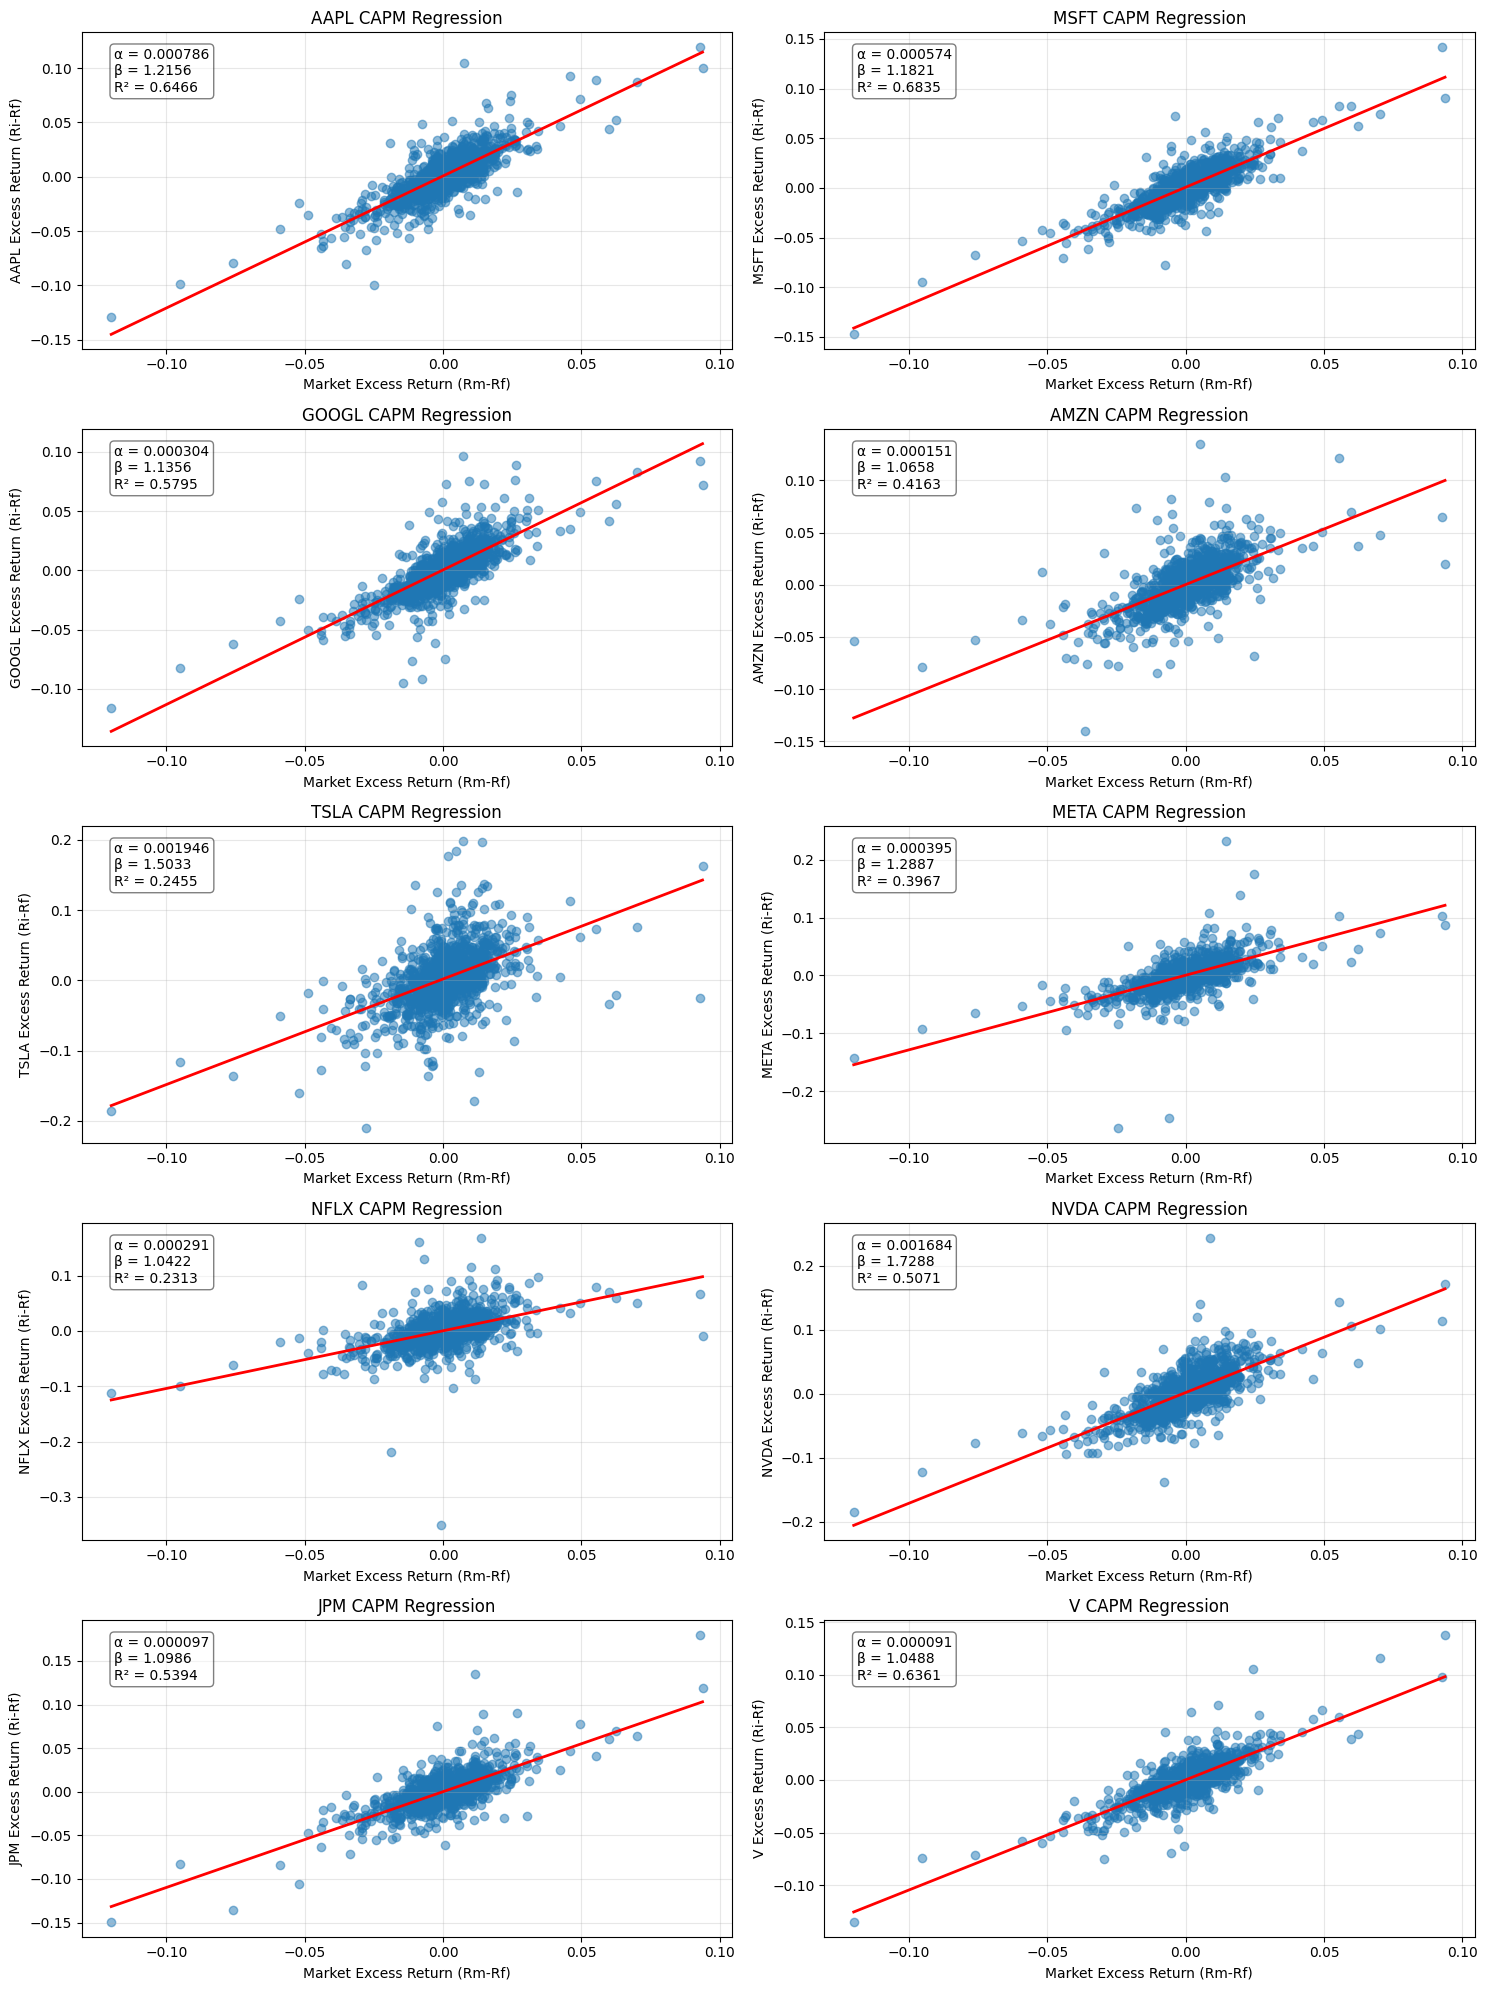

In [ ]:
# Visualize the CAPM linear regression for each asset using sklearn
import matplotlib.pyplot as plt
from sklearn import linear_model

# Create a figure with subplots for each of the 10 asset
fig, axes = plt.subplots(5, 2, figsize=(15, 20))

axes = axes.flatten()  # Flatten FOR indexing

# Plot regression for each of the 10 asset
for i, asset in enumerate(assets):
    # Get data for this asset
    x = market_returns.values.reshape(-1, 1)
    y = assets_returns[asset].values

    # Fit the linear model using sklearn
    regr = linear_model.LinearRegression()
    regr.fit(x, y)

    # Get the coefficients
    sklearn_alpha = regr.intercept_
    sklearn_beta = regr.coef_[0]

    # Plot the scatter points
    axes[i].scatter(x, y, alpha=0.5)

    # Plot the linear regression line
    x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
    y_pred = regr.predict(x_line)
    axes[i].plot(x_line, y_pred, 'r-', linewidth=2)

    # Add the writing for the regression coefficients
    r_squared = regr.score(x, y)
    message = f"α = {sklearn_alpha:.6f}\nβ = {sklearn_beta:.4f}\nR² = {r_squared:.4f}"
    # Change text to message
    axes[i].text(0.05, 0.95, message, transform=axes[i].transAxes, fontsize=10,verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

    # Set labels taken from the CAMP formula
    axes[i].set_title(f"{asset} CAPM Regression")
    axes[i].set_xlabel("Market Excess Return (Rm-Rf)")
    axes[i].set_ylabel(f"{asset} Excess Return (Ri-Rf)")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('capm_regression_plots_sklearn.png', dpi=300)
plt.show()

In [ ]:
# create a dispaly table for the  CAPM regression results
import pandas as pd

# DataFrame
results_data = []
for asset in assets:
    results_data.append({
        'Asset': asset,
        'Alpha': alphas[asset],
        'Beta': betas[asset],
        'Expected Return': expected_returns[asset],
        'Idiosyncratic Risk': idiosyncratic_var[asset]
    })

results_df = pd.DataFrame(results_data)

print("\nCAPM Regression Results Summary:")
print(results_df)

results_df


CAPM Regression Results Summary:
   Asset     Alpha      Beta  Expected Return  Idiosyncratic Risk
0   AAPL  1.215624  0.000786         0.000080            0.000412
1   MSFT  1.182135  0.000574         0.000080            0.000369
2  GOOGL  1.135638  0.000304         0.000080            0.000401
3   AMZN  1.065801  0.000151         0.000079            0.000492
4   TSLA  1.503262  0.001946         0.000080            0.001660
5   META  1.288666  0.000395         0.000080            0.000755
6   NFLX  1.042221  0.000291         0.000080            0.000846
7   NVDA  1.728839  0.001684         0.000080            0.001063
8    JPM  1.098643  0.000097         0.000079            0.000403
9      V  1.048806  0.000091         0.000079            0.000312


,Asset,Alpha,Beta,Expected Return,Idiosyncratic Risk
0,AAPL,1.215624,0.000786,0.000080,0.000412
1,MSFT,1.182135,0.000574,0.000080,0.000369
2,GOOGL,1.135638,0.000304,0.000080,0.000401
3,AMZN,1.065801,0.000151,0.000079,0.000492
4,TSLA,1.503262,0.001946,0.000080,0.001660
5,META,1.288666,0.000395,0.000080,0.000755
6,NFLX,1.042221,0.000291,0.000080,0.000846
7,NVDA,1.728839,0.001684,0.000080,0.001063
8,JPM,1.098643,0.000097,0.000079,0.000403
9,V,1.048806,0.000091,0.000079,0.000312


In [31]:


# Construct the  covariance matrix
n_assets = len(assets)
Sigma = np.zeros((n_assets, n_assets))

for i in range(n_assets):
    for j in range(n_assets):
        if i == j:
            # systematic risk and idiosyncratic risk
            # Convert to a float
            beta_i = float(betas[assets[i]])
            idio_var_i = float(idiosyncratic_var[assets[i]])
            Sigma[i, j] = (beta_i ** 2 * market_variance) + idio_var_i
        else:
            # systematic risk
            # Convert to a float
            beta_i = float(betas[assets[i]])
            beta_j = float(betas[assets[j]])
            Sigma[i, j] = beta_i * beta_j * market_variance

print("\nCovariance Matrix:")
print(Sigma)


Covariance Matrix:
[[4.11999843e-04 8.13943235e-11 4.30494908e-11 2.14346469e-11
  2.75724067e-10 5.59580842e-11 4.12616560e-11 2.38618225e-10
  1.37475871e-11 1.28537321e-11]
 [8.13943235e-11 3.68631894e-04 3.14588999e-11 1.56636095e-11
  2.01488465e-10 4.08919997e-11 3.01524195e-11 1.74372953e-10
  1.00462040e-11 9.39300939e-12]
 [4.30494908e-11 3.14588999e-11 4.01218982e-04 8.28448942e-12
  1.06567331e-10 2.16277953e-11 1.59476269e-11 9.22259258e-11
  5.31344137e-12 4.96796649e-12]
 [2.14346469e-11 1.56636095e-11 8.28448942e-12 4.91888687e-04
  5.30606303e-11 1.07686327e-11 7.94043661e-12 4.59199429e-11
  2.64560016e-12 2.47358577e-12]
 [2.75724067e-10 2.01488465e-10 1.06567331e-10 5.30606303e-11
  1.65982670e-03 1.38522049e-10 1.02141616e-10 5.90690084e-10
  3.40316142e-11 3.18189112e-11]
 [5.59580842e-11 4.08919997e-11 2.16277953e-11 1.07686327e-11
  1.38522049e-10 7.54786118e-04 2.07295983e-11 1.19880306e-10
  6.90670189e-12 6.45763473e-12]
 [4.12616560e-11 3.01524195e-11 1.5947

<ipython-input-31-1ed9d3261539>:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  Sigma[i, j] = (beta_i ** 2 * market_variance) + idio_var_i
<ipython-input-31-1ed9d3261539>:18: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  Sigma[i, j] = beta_i * beta_j * market_variance


In [32]:
mu = np.array([expected_returns[asset] for asset in assets])

# Chose a target return somewhere in the middle of the minimum and maximum expected returns of the assets.
min_return = min(mu)
max_return = max(mu)
target_return = (min_return + max_return) / 2

# Set up the quadratic programming problem
n = len(assets)

# Create the model
m = gp.Model('portfolio')

# No short selling
x = m.addMVar(n, lb=0, name='weights')

# Set the portfolio risk objective
portfolio_risk = 0.5 * (x @ Sigma @ x)
m.setObjective(portfolio_risk, GRB.MINIMIZE)

# Set the investment constraint
m.addConstr(x.sum() == 1, 'budget')

# Add the target return constraint
m.addConstr(gp.quicksum(mu[i] * x[i] for i in range(n)) == target_return, 'target_return')

# Verify the model
m.write('portfolio_selection_optimization.lp')

# Optimize the model
m.optimize()

# Print results if optimization is successful
if m.status == GRB.OPTIMAL:
    print("\nOptimal Portfolio Weights:")
    for i, asset in enumerate(assets):
        print(f"{asset}: {x.X[i]:.4f}")

    # Calculate the  expected portfolio returns and risks
    expected_portfolio_return = sum(mu[i] * x.X[i] for i in range(n))
    portfolio_variance = sum(Sigma[i, j] * x.X[i] * x.X[j] for i in range(n) for j in range(n))
    portfolio_std = np.sqrt(portfolio_variance)

    print(f"\nExpected Portfolio Return: {expected_portfolio_return:.6f}")
    print(f"Portfolio Risk (Standard Deviation): {portfolio_std:.6f}")
else:
    print("\nOptimization was not successful. Status code:", m.status)


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [ ]:
#creates a tables for the optimal portfolio weights
weights = {}
for i, asset in enumerate(assets): #

    weights[asset] = x.X[i]

# Create a pandas DataFrame from the weights dictionary
weights_df = pd.DataFrame(weights, index=['Weight'])
weights_df = weights_df.T

# Display the table
print("\nOptimal Portfolio Weights:")
display(weights_df)


# Print expected portfolio returns and risks
print(f"\nExpected Portfolio Return: {expected_portfolio_return:.6f}")
print(f"Portfolio Risk (Standard Deviation): {portfolio_std:.6f}")



Optimal Portfolio Weights:


,Weight
AAPL,0.239705
MSFT,0.187784
GOOGL,0.078407
AMZN,0.020676
TSLA,0.157013
META,0.058522
NFLX,0.035083
NVDA,0.210850
JPM,0.006443
V,0.005518



Expected Portfolio Return: 0.000080
Portfolio Risk (Standard Deviation): 0.011453


Table of the Portfolio Weights

In [ ]:
min_return = float(min_return)
max_return = float(max_return)
target_return = float(target_return)



In [ ]:
# Solve for efficient frontier by varying the targets  target return

frontier = np.empty((2, 0))

m_ef = m.copy()

# Get the target return constraint
target = m_ef.getConstrByName('target_return')

for r in np.linspace(min_return, max_return, 10):# 10 targets chosen between the maximum and minim expected returns
    target.rhs = r  # Update the target return
    m_ef.optimize()


    if m_ef.status == GRB.OPTIMAL:
        frontier = np.append(frontier, [[np.sqrt(m_ef.objVal)], [r]], axis=1)
    else:
        print(f"Optimization failed for target return {r:.6f}")

# Assign the calculated frontier data to efficient_frontier for plotting
efficient_frontier = list(zip(frontier[0], frontier[1])) # Transpose and convert to list of tuples

Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 2 rows, 10 columns and 20 nonzeros
Model fingerprint: 0x5e477d91
Model has 55 quadratic objective terms
Coefficient statistics:
  Matrix range     [8e-05, 1e+00]
  Objective range  [0e+00, 0e+00]
  QObjective range [3e-12, 2e-03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [8e-05, 1e+00]
Presolve time: 0.01s
Presolved: 2 rows, 10 columns, 20 nonzeros
Presolved model has 55 quadratic objective terms
Ordering time: 0.00s

Barrier statistics:
 Free vars  : 9
 AA' NZ     : 5.500e+01
 Factor NZ  : 6.600e+01
 Factor Ops : 5.060e+02 (less than 1 second per iteration)
 Threads    : 1

                  Objective                Residual
Iter       Primal          Dual         Primal    Dual     Compl     Time
   0   2.95021861e+03 -2

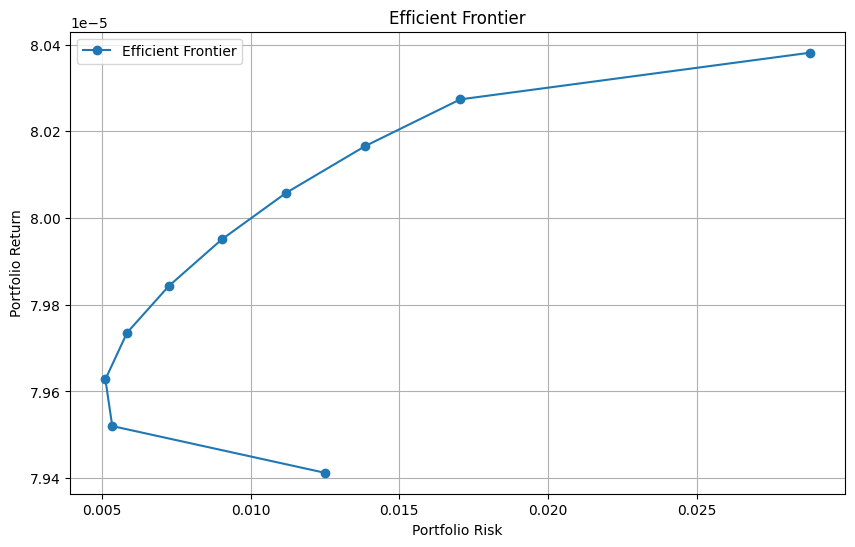

In [ ]:
#plot the efficient frontier
risks, returns = zip(*efficient_frontier)
plt.figure(figsize=(10, 6))
plt.plot(risks, returns, marker = 'o', label = 'Efficient Frontier')
#plt.scatter(std, mu, color='Blue', label='Individual Stocks
plt.xlabel('Portfolio Risk')
plt.ylabel('Portfolio Return')
plt.title('Efficient Frontier')
plt.legend()
plt.grid()
plt.show()

print()